In [235]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [236]:

k = symbols('k', positive=True, real=True)
l = symbols('ell', positive=True, real=True)

b = symbols('beta', positive=True, real=True)

A = symbols('A', positive=True, real=True)


H = symbols('H', positive=True, real=True)


ED = (S(2)/pi) * (A**S(2) / (A**S(2) + k**S(2)))**(b/S(2))
display(ED.simplify())

D = symbols('D', positive=True, integer=True)
D = S(1)
ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD.simplify())

eq_ED = S(1)/S(2) * l**2 * diff(2 * integrate((S(1)-ftD)*ED, (k, 0, oo)), l)
eq_ED = eq_ED.simplify().args[0][0]#.subs({b: S(1) + S(2)*H}).simplify()
display(eq_ED.simplify())

display(eq_ED.subs({b: S(1) + S(2)*H}).simplify())

dd = (l * diff(ln(eq_ED), l)).simplify()
display(dd)

powerlaw = limit(dd.subs({b: S(2)}), l, 0).simplify()
display(powerlaw)


2*(A/sqrt(A**2 + k**2))**beta/pi

cos(ell*k)

sqrt(pi)*(A*ell/2)**(beta/2 + 1/2)*(A*ell*besseli(3/2 - beta/2, A*ell) + A*ell*besseli(-beta/2 - 1/2, A*ell) - A*ell*besseli(beta/2 - 3/2, A*ell) - A*ell*besseli(beta/2 + 1/2, A*ell) + beta*besseli(1/2 - beta/2, A*ell) - beta*besseli(beta/2 - 1/2, A*ell) - besseli(1/2 - beta/2, A*ell) + besseli(beta/2 - 1/2, A*ell))/(cos(pi*beta/2)*gamma(beta/2))

sqrt(pi)*(A*ell/2)**(H + 1)*(-A*ell*besseli(1 - H, A*ell) - A*ell*besseli(-H - 1, A*ell) + A*ell*besseli(H - 1, A*ell) + A*ell*besseli(H + 1, A*ell) - 2*H*besseli(-H, A*ell) + 2*H*besseli(H, A*ell))/(sin(pi*H)*gamma(H + 1/2))

(A**2*ell**2*besseli(1/2 - beta/2, A*ell) + A**2*ell**2*besseli(5/2 - beta/2, A*ell)/2 + A**2*ell**2*besseli(-beta/2 - 3/2, A*ell)/2 - A**2*ell**2*besseli(beta/2 - 5/2, A*ell)/2 - A**2*ell**2*besseli(beta/2 - 1/2, A*ell) - A**2*ell**2*besseli(beta/2 + 3/2, A*ell)/2 + A*beta*ell*besseli(3/2 - beta/2, A*ell) + A*beta*ell*besseli(-beta/2 - 1/2, A*ell) - A*beta*ell*besseli(beta/2 - 3/2, A*ell) - A*beta*ell*besseli(beta/2 + 1/2, A*ell) + A*ell*besseli(3/2 - beta/2, A*ell) + A*ell*besseli(-beta/2 - 1/2, A*ell) - A*ell*besseli(beta/2 - 3/2, A*ell) - A*ell*besseli(beta/2 + 1/2, A*ell) + beta**2*besseli(1/2 - beta/2, A*ell)/2 - beta**2*besseli(beta/2 - 1/2, A*ell)/2 - besseli(1/2 - beta/2, A*ell)/2 + besseli(beta/2 - 1/2, A*ell)/2)/(A*ell*besseli(3/2 - beta/2, A*ell) + A*ell*besseli(-beta/2 - 1/2, A*ell) - A*ell*besseli(beta/2 - 3/2, A*ell) - A*ell*besseli(beta/2 + 1/2, A*ell) + beta*besseli(1/2 - beta/2, A*ell) - beta*besseli(beta/2 - 1/2, A*ell) - besseli(1/2 - beta/2, A*ell) + besseli(beta/2

3/2

In [297]:
R = integrate(ftD * ED, (k, 0, oo))
display(R.simplify().subs({b: S(2)}).expand(func=True).simplify())

A*exp(-A*ell)

In [237]:
test = eq_ED.subs({b: S(1) + S(2)*H}).simplify()
display(test)
test2 = test.expand(func=True)
display(test2.simplify())

sqrt(pi)*(A*ell/2)**(H + 1)*(-A*ell*besseli(1 - H, A*ell) - A*ell*besseli(-H - 1, A*ell) + A*ell*besseli(H - 1, A*ell) + A*ell*besseli(H + 1, A*ell) - 2*H*besseli(-H, A*ell) + 2*H*besseli(H, A*ell))/(sin(pi*H)*gamma(H + 1/2))

sqrt(pi)*(A*ell)**(H + 2)*(-besseli(1 - H, A*ell) + besseli(H - 1, A*ell))/(2**H*sin(pi*H)*gamma(H + 1/2))

In [238]:
## EQUIVALENT SF TERMS

term = sqrt(pi) * ((A*l)/S(2))**(H + S(1)) / (sin(pi*H) * gamma(H + Rational(1,2)))

b_terms = [
    - A*l*besseli(S(1)-H, A*l),
    A*l*besseli(H-S(1), A*l),

    - A*l*besseli(-H-S(1), A*l),
    A*l*besseli(H+S(1), A*l),

    -S(2)*H*besseli(-H, A*l),
    S(2)*H*besseli(H, A*l)
]

#term = ((A*l)/S(2))**(b/S(2) + Rational(1,2)) * sqrt(pi) / (cos(pi*b/S(2)) * gamma(b/S(2)))
#display(term)

# b_terms = [
#     -A*l*besseli(b/S(2) - Rational(3,2), A*l),
#     A*l*besseli(Rational(3,2) - b/S(2), A*l),

#     -A*l*besseli(b/S(2) + Rational(1,2), A*l),
#     A*l*besseli(-b/S(2) - Rational(1,2), A*l),

#     -b*besseli(b/S(2) - Rational(1,2), A*l),
#     b*besseli(Rational(1,2) - b/S(2), A*l),

#     -besseli(Rational(1,2) - b/S(2), A*l),
#     besseli(b/S(2) - Rational(1,2), A*l)
# ]

_l = 10.**(np.linspace(np.log10(1e-5), np.log10(10.), 1000))
eqs = [np.zeros_like(_l) for _ in range(len(b_terms))]

t_eq = np.zeros_like(_l)

h = Rational(1,2)

for i, __l in enumerate(_l):
    for j, t in enumerate(b_terms):
        val = t.subs({A: S(1), l: __l, H: h})
        eqs[j][i] = val
        val = term.subs({A: S(1), l: __l, H: h})
        t_eq[i] = val


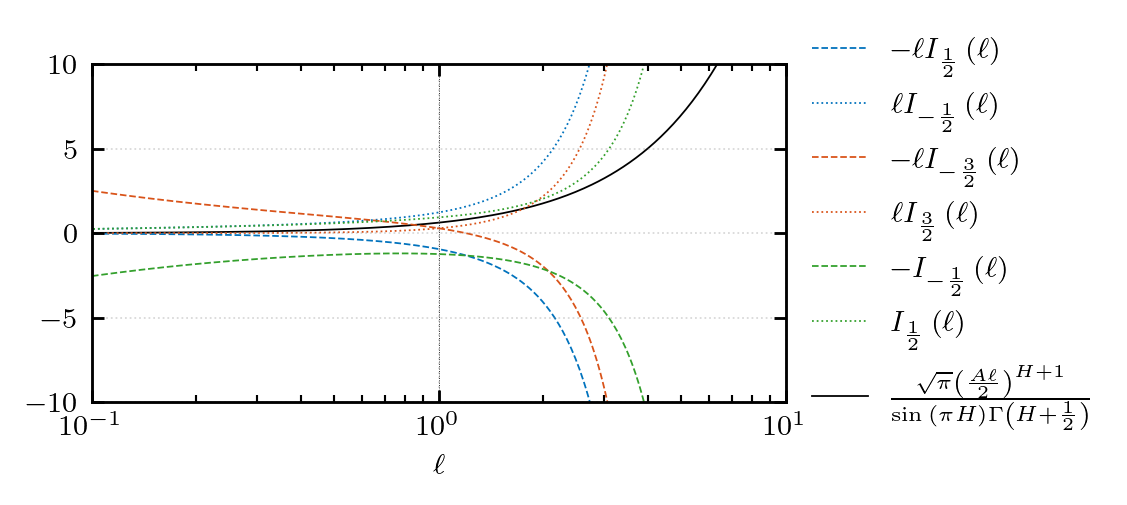

In [239]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, eqs[0], linestyle='--', color=c[0], linewidth=0.5, label=r'$%s$' % latex(b_terms[0].subs({A: S(1), H: h})), zorder=1)
ax.plot(_l, eqs[1], linestyle=':', color=c[0], linewidth=0.5, label=r'$%s$' % latex(b_terms[1].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, eqs[2], linestyle='--', color=c[1], linewidth=0.5, label=r'$%s$' % latex(b_terms[2].subs({A: S(1), H: h})), zorder=1)
ax.plot(_l, eqs[3], linestyle=':', color=c[1], linewidth=0.5, label=r'$%s$' % latex(b_terms[3].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, eqs[4], linestyle='--', color=c[2], linewidth=0.5, label=r'$%s$' % latex(b_terms[4].subs({A: S(1), H: h})), zorder=1)
ax.plot(_l, eqs[5], linestyle=':', color=c[2], linewidth=0.5, label=r'$%s$' % latex(b_terms[5].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, t_eq, linestyle='-', color='black', linewidth=0.5, label=r'$%s$' % latex(term), zorder=0)

# for __x in _x:
#     val = ED.subs({w: __x}).evalf()
#     ax.scatter(__x, val, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_xscale('log')
ax.set_ylim((-10, 10))
ax.set_xlim((1e-1, 1e1))

ax.set_xlabel(r'$\ell$')

# ax.set_ylim((3e-4, 8e-1))
# ax.set_xlim((0.3, 110))

#ax.legend(loc='lower left')
ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


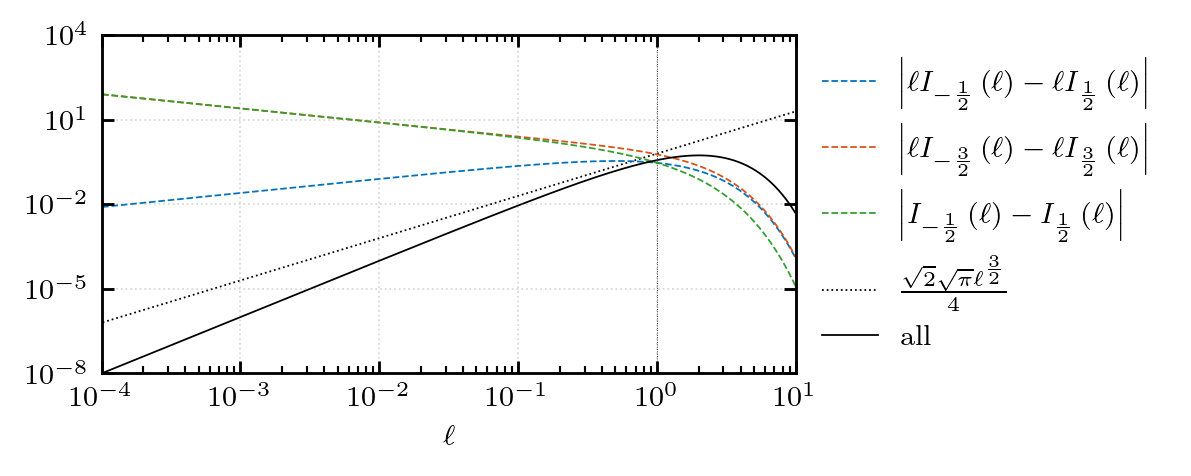

In [240]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, np.abs(eqs[0]+eqs[1]), linestyle='--', color=c[0], linewidth=0.5, label=r'$%s$' % latex(abs(b_terms[0].subs({A: S(1), H: h})+b_terms[1].subs({A: S(1), H: h}))), zorder=1)
#ax.plot(_l, eqs[1], linestyle=':', color=c[0], linewidth=0.5, label=r'$%s$' % latex(b_terms[1].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, np.abs(eqs[2]+eqs[3]), linestyle='--', color=c[1], linewidth=0.5, label=r'$%s$' % latex(abs(b_terms[2].subs({A: S(1), H: h})+b_terms[3].subs({A: S(1), H: h}))), zorder=1)
#ax.plot(_l, eqs[3], linestyle=':', color=c[1], linewidth=0.5, label=r'$%s$' % latex(b_terms[3].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, np.abs(eqs[4]+eqs[5]), linestyle='--', color=c[2], linewidth=0.5, label=r'$%s$' % latex(abs(b_terms[4].subs({A: S(1), H: h})+b_terms[5].subs({A: S(1), H: h}))), zorder=1)
#ax.plot(_l, eqs[5], linestyle=':', color=c[2], linewidth=0.5, label=r'$%s$' % latex(b_terms[5].subs({A: S(1), H: h})), zorder=1)

ax.plot(_l, t_eq, linestyle=':', color='black', linewidth=0.5, label=r'$%s$' % latex(term.subs({A: S(1), H: h})), zorder=0)

ax.plot(_l, t_eq * (eqs[0]+eqs[1]+eqs[2]+eqs[3]+eqs[4]+eqs[5]), color='black', linewidth=0.5, label='all', zorder=1)

# for __x in _x:
#     val = ED.subs({w: __x}).evalf()
#     ax.scatter(__x, val, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim((1e-8, 1e4))
ax.set_xlim((1e-4, 1e1))

ax.set_xlabel(r'$\ell$')

# ax.set_ylim((3e-4, 8e-1))
# ax.set_xlim((0.3, 110))

#ax.legend(loc='lower left')
ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


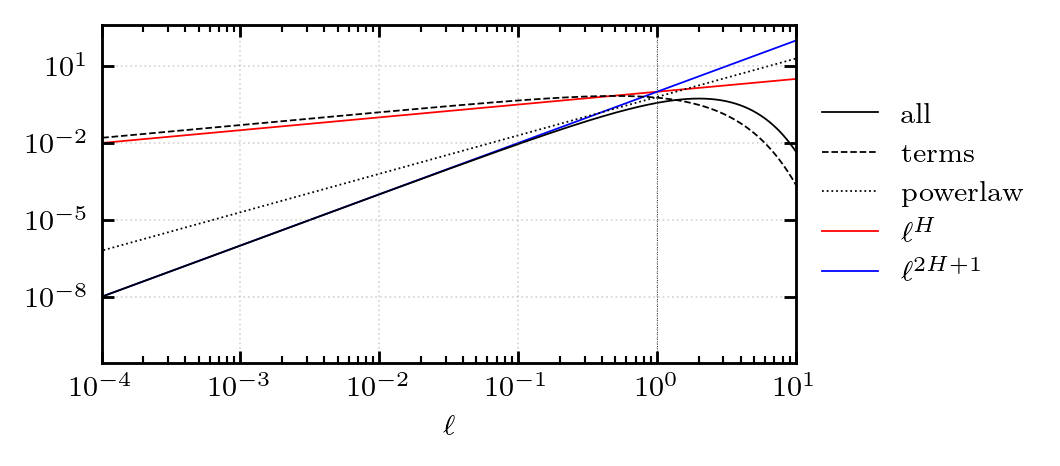

In [241]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

ax.plot(_l, t_eq * (eqs[0]+eqs[1]+eqs[2]+eqs[3]+eqs[4]+eqs[5]), color='black', linewidth=0.5, label='all', zorder=1)

ax.plot(_l, abs(eqs[0]+eqs[1]+eqs[2]+eqs[3]+eqs[4]+eqs[5]), color='black', linestyle='--', linewidth=0.5, label='terms', zorder=1)

ax.plot(_l, abs(t_eq), linestyle=':', color='black', linewidth=0.5, label='powerlaw', zorder=1)

ax.plot(_l, _l**(h), linestyle='-', color='red', linewidth=0.5, label=r'$\ell^{H}$', zorder=0)
ax.plot(_l, _l**(2*h+1), linestyle='-', color='blue', linewidth=0.5, label=r'$\ell^{2H + 1}$', zorder=0)

# ax.plot(_l, eqs[2]+eqs[3], linestyle='--', color=c[0], linewidth=0.5, label=r'$%s$' % latex(b_terms[0].subs({A: S(1), H: h})+b_terms[1].subs({A: S(1), H: h})), zorder=1)
# ax.plot(_l, np.abs(eqs[4]+eqs[5]), linestyle='--', color=c[2], linewidth=0.5, label=r'$%s$' % latex(abs(b_terms[4].subs({A: S(1), H: h})+b_terms[5].subs({A: S(1), H: h}))), zorder=1)

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim((1e-4, 1e2))
ax.set_xlim((1e-4, 1e1))

ax.set_xlabel(r'$\ell$')

#ax.legend(loc='lower left')
ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)


In [287]:

M = symbols('M', integer=True)
m = symbols('m', integer=True)

for e in b_terms:
    display(e)

bessel_sum = Sum((l/2)**(2*m+H) / (gamma(m+1) * gamma(m + H + 1)), (m, 0, oo))

b_terms_e = [
    - A*l*Sum((A*l/2)**(2*m+(1-H)) / (gamma(m+1) * gamma(m + (1-H) + 1)), (m, 0, M)),
    A*l*Sum((A*l/2)**(2*m+(H-1)) / (gamma(m+1) * gamma(m + (H-1) + 1)), (m, 0, M)),

    - A*l*Sum((A*l/2)**(2*m+(-1-H)) / (gamma(m+1) * gamma(m + (-1-H) + 1)), (m, 0, M)),
    A*l*Sum((A*l/2)**(2*m+(1+H)) / (gamma(m+1) * gamma(m + (1+H) + 1)), (m, 0, M)),

    - 2*H*Sum((A*l/2)**(2*m-H) / (gamma(m+1) * gamma(m - H + 1)), (m, 0, M)),
    2*H*Sum((A*l/2)**(2*m+H) / (gamma(m+1) * gamma(m + H + 1)), (m, 0, M)),
]

for e in b_terms_e:
    display(e)
    display(e.subs({M: 1}).simplify())

sum_terms = b_terms_e[0] + b_terms_e[1] + b_terms_e[2] + b_terms_e[3] + b_terms_e[4] + b_terms_e[5]

display(sum_terms)

expanded = expand(sum_terms.subs({M: 2})).simplify()

display(expanded)

#display((expanded + Order(l**2)).simplify())


-A*ell*besseli(1 - H, A*ell)

A*ell*besseli(H - 1, A*ell)

-A*ell*besseli(-H - 1, A*ell)

A*ell*besseli(H + 1, A*ell)

-2*H*besseli(-H, A*ell)

...

-2*H*(2**H/(A**H*ell**H*gamma(1 - H)) + 2**(H - 2)*A**(2 - H)*ell**(2 - H)/gamma(2 - H))

2*H*Sum((A*ell/2)**(H + 2*m)/(gamma(m + 1)*gamma(H + m + 1)), (m, 0, M))

2*H*(2**(-H - 2)*A**(H + 2)*ell**(H + 2)/gamma(H + 2) + A**H*ell**H/(2**H*gamma(H + 1)))

-A*ell*Sum((A*ell/2)**(-H + 2*m - 1)/(gamma(-H + m)*gamma(m + 1)), (m, 0, M)) - A*ell*Sum((A*ell/2)**(-H + 2*m + 1)/(gamma(m + 1)*gamma(-H + m + 2)), (m, 0, M)) + A*ell*Sum((A*ell/2)**(H + 2*m - 1)/(gamma(H + m)*gamma(m + 1)), (m, 0, M)) + A*ell*Sum((A*ell/2)**(H + 2*m + 1)/(gamma(m + 1)*gamma(H + m + 2)), (m, 0, M)) - 2*H*Sum((A*ell/2)**(-H + 2*m)/(gamma(m + 1)*gamma(-H + m + 1)), (m, 0, M)) + 2*H*Sum((A*ell/2)**(H + 2*m)/(gamma(m + 1)*gamma(H + m + 1)), (m, 0, M))

2**(2 - H)*A**H*H*ell**H/gamma(H + 1) + 2**(-H - 1)*A**(H + 2)*ell**(H + 2)/gamma(H + 2) - 2**(H - 1)*A**(2 - H)*ell**(2 - H)/gamma(2 - H) + A**4*ell**4*(-2*2**H/(A**H*ell**H*gamma(3 - H)) + 2**(2 - H)*A**H*H*ell**H/(2*gamma(H + 3)) + 2**(-H - 1)*A**(H + 2)*ell**(H + 2)/(2*gamma(H + 4)) - 2**(H - 1)*A**(2 - H)*ell**(2 - H)/(2*gamma(4 - H)) + 2*A**H*ell**H/(2**H*gamma(H + 3)))/16 + A**2*ell**2*(-2*2**H/(A**H*ell**H*gamma(2 - H)) + 2**(2 - H)*A**H*H*ell**H/gamma(H + 2) + 2**(-H - 1)*A**(H + 2)*ell**(H + 2)/gamma(H + 3) - 2**(H - 1)*A**(2 - H)*ell**(2 - H)/gamma(3 - H) + 2*A**H*ell**H/(2**H*gamma(H + 2)))/4

In [288]:

#display((expanded + O(l**2)).simplify())

display((expanded.subs({H: Rational(3,2)}) + Order(l**8)).simplify())
terms = expand(sum_terms.subs({M: 0})).simplify().args
display(terms)


(sqrt(2)*pi*sqrt(A)*sqrt(ell)*(A**2*ell**2*(A**2*ell**2*(A**3*ell**3 + 90*A*ell - 315) - 3780) + 36*A**2*ell**2*(A**3*ell**3 + 56*A*ell - 105) - 7560) + 504*sqrt(2)*pi*sqrt(A)*sqrt(ell)*(A**3*ell**3 + 30*A*ell - 15) + O(ell**8))/(7560*pi**(3/2))

(2**(-H - 1)*A**(H + 2)*ell**(H + 2)/gamma(H + 2),
 -2**(H - 1)*A**(2 - H)*ell**(2 - H)/gamma(2 - H),
 2**(2 - H)*A**H*H*ell**H/gamma(H + 1))

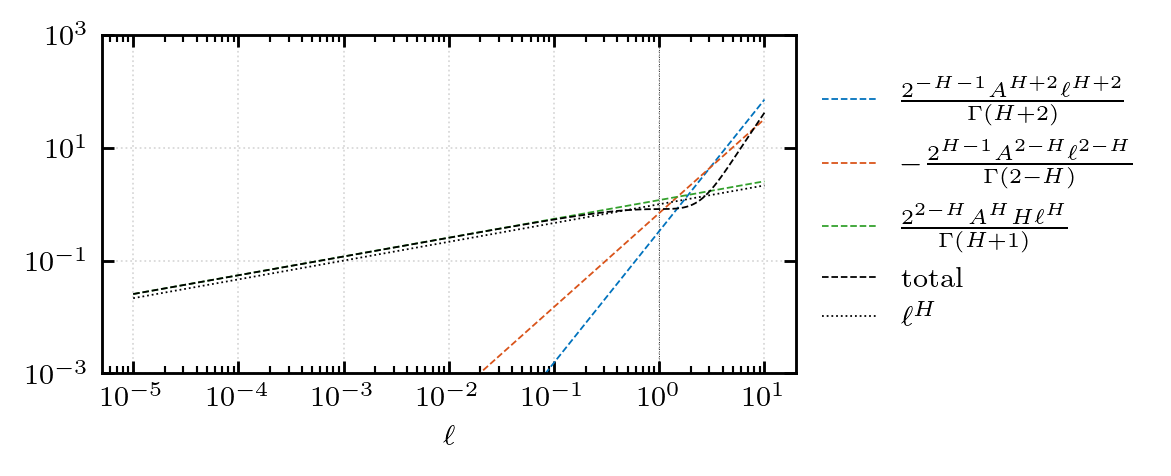

In [296]:

terms = expand(sum_terms.subs({M: 0})).simplify().args

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

h2 = Rational(1,3)

eq = [np.zeros_like(_l) for _ in range(len(terms))]

for i, __l in enumerate(_l):
    for j, t in enumerate(terms):
        eq[j][i] = terms[j].subs({l: __l, H: h2, A: S(1)}).evalf()

for i in range(len(eq)):
    ax.plot(_l, abs(eq[i]), color=c[i], linestyle='--', linewidth=0.5, label=r'$%s$' % latex(terms[i]))

ax.plot(_l, np.sum(eq, axis=0), color='black', linestyle='--', linewidth=0.5, label=r'total')

ax.plot(_l, _l**(h2.evalf()), color='black', linestyle=':', linewidth=0.5, label=r'$\ell^H$')

ax.axvline(1, linestyle=':', color='black', linewidth=0.25, zorder=0)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylim((1e-3, 1e3))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel(r'$\ell$')

ax.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5), fancybox=False, shadow=False, frameon=False)
